In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel('Health Insurance Dataset Dataset.xlsx')

In [8]:
display (df)

,age,sex,bmi,children,smoker,region,charges,Level,score
0,19.0,female,27.900,0.0,yes,southwest,16884.924,B,72.0
1,18.0,male,33.770,1.0,no,southeast,1725.5523,C,69.0
2,28.0,male,33.000,3.0,no,southeast,4449.462,B,90.0
3,33.0,male,22.705,0.0,no,northwest,21984.47061,A,47.0
4,32.0,male,28.880,0.0,no,northwest,3866.8552,C,76.0
...,...,...,...,...,...,...,...,...,...
1335,18.0,female,36.850,0.0,no,southeast,1629.8335,B,61.0
1336,21.0,female,25.800,0.0,no,southwest,2007.945,D,76.0
1337,61.0,female,29.070,0.0,yes,northwest,29141.3603,C,49.0
1338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.duplicated().sum()

0

In [10]:
df.isna().sum()

age         2
sex         2
bmi         2
children    2
smoker      2
region      1
charges     1
Level       2
score       2
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
Level       0
score       0
dtype: int64

In [13]:
display (df)

,age,sex,bmi,children,smoker,region,charges,Level,score
0,19.0,female,27.900,0.0,yes,southwest,16884.924,B,72.0
1,18.0,male,33.770,1.0,no,southeast,1725.5523,C,69.0
2,28.0,male,33.000,3.0,no,southeast,4449.462,B,90.0
3,33.0,male,22.705,0.0,no,northwest,21984.47061,A,47.0
4,32.0,male,28.880,0.0,no,northwest,3866.8552,C,76.0
...,...,...,...,...,...,...,...,...,...
1333,50.0,male,30.970,3.0,no,northwest,10600.5483,B,90.0
1334,18.0,female,31.920,0.0,no,northeast,2205.9808,C,83.0
1335,18.0,female,36.850,0.0,no,southeast,1629.8335,B,61.0
1336,21.0,female,25.800,0.0,no,southwest,2007.945,D,76.0


Text(0.5, 1.0, 'Distribution of Age')

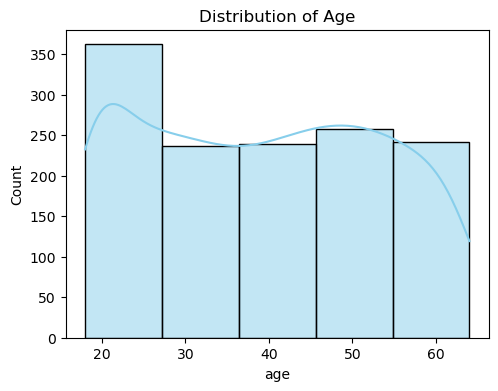

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Age')

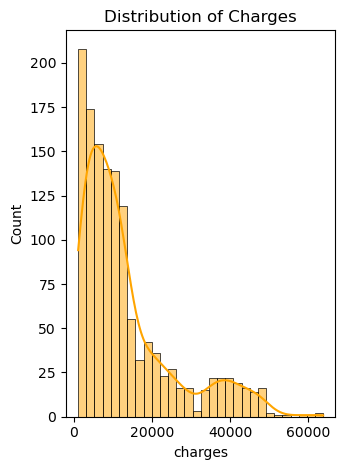

In [15]:
plt.subplot(1, 2, 2)
sns.histplot(df['charges'], kde=True, color='orange')
plt.title('Distribution of Charges')
plt.tight_layout()
plt.show()

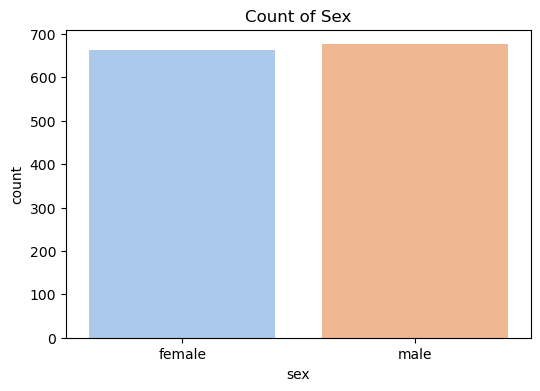

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=df, hue='sex', palette='pastel', legend=False)
plt.title('Count of Sex')
plt.show()

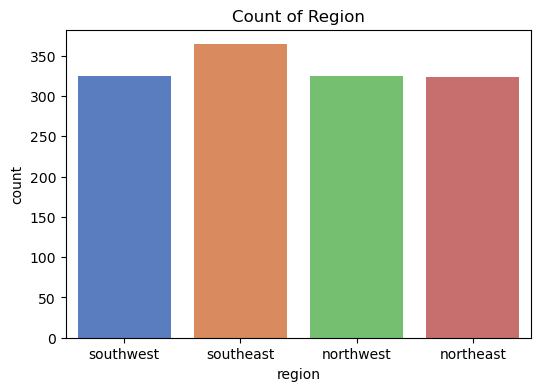

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(x='region', data=df, hue='region', palette='muted', legend=False)
plt.title('Count of Region')
plt.show()

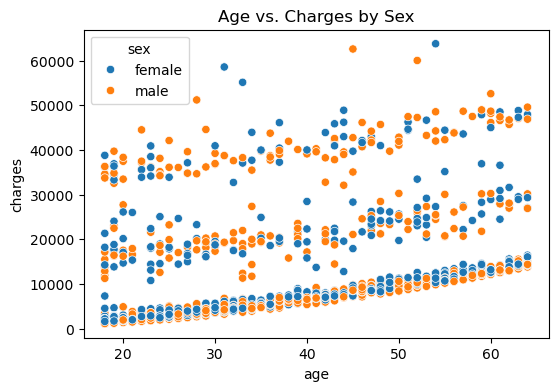

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='age', y='charges', hue='sex', data=df)
plt.title('Age vs. Charges by Sex')
plt.show()

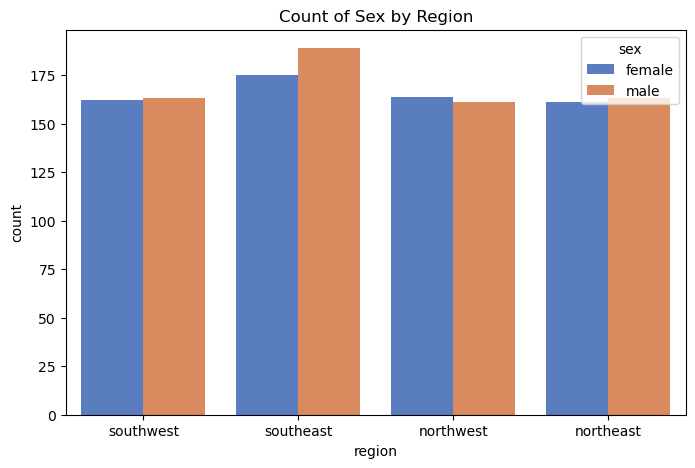

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x='region', hue='sex', data=df, palette='muted')
plt.title('Count of Sex by Region')
plt.show()

In [30]:
print(df.dtypes)

age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges      object
Level        object
score       float64
dtype: object


In [31]:
df['charges'] = df['charges'].astype('float64')

In [32]:
from scipy.stats import ttest_ind

smokers = df[df['smoker'] == 'yes']['charges']
nonsmokers = df[df['smoker'] == 'no']['charges']

t_stat, p_value = ttest_ind(smokers, nonsmokers, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")


T-statistic: 32.752, P-value: 0.00000


In [33]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Level'], df['region'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2:.3f}, P-value: {p:.5f}")

Chi2: 13.933, P-value: 0.30498
